In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
df = pd.read_csv(r"C:/College/CSE-AI/4th Sem/DL/DL_Lab/Tweets.csv")
print(df.head())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [5]:
df = df[['text','sentiment']]
print(df.head())

                                                text sentiment
0                I`d have responded, if I were going   neutral
1      Sooo SAD I will miss you here in San Diego!!!  negative
2                          my boss is bullying me...  negative
3                     what interview! leave me alone  negative
4   Sons of ****, why couldn`t they put them on t...  negative


In [6]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [7]:
print(df['sentiment'])

0        1
1        0
2        0
3        0
4        0
        ..
27476    0
27477    0
27478    2
27479    2
27480    1
Name: sentiment, Length: 27481, dtype: int64


In [8]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)   # remove links
    text = re.sub(r'@\w+', '', text)      # remove mentions
    text = re.sub(r'[^a-zA-Z ]', '', text) # remove special chars
    return text

df['text'] = df['text'].fillna('').astype(str)
df['text'] = df['text'].apply(clean_text)

In [9]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X, maxlen=100)

y = df['sentiment']

In [10]:
print(df['text'].isnull().sum())

0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',     # watch validation performance
    patience=2,            # stop after 2 bad epochs
    restore_best_weights=True
)

In [13]:
rnn_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')   # 3 sentiments
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_model.summary()

c:\Users\praga\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.5312 - loss: 0.9369 - val_accuracy: 0.6534 - val_loss: 0.7929
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7335 - loss: 0.6437 - val_accuracy: 0.6813 - val_loss: 0.7542
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.8317 - loss: 0.4473 - val_accuracy: 0.6738 - val_loss: 0.8349
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.9071 - loss: 0.2713 - val_accuracy: 0.6562 - val_loss: 1.0625


In [15]:
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 55s 138ms/step - accuracy: 0.6003 - loss: 0.8463 - val_accuracy: 0.7035 - val_loss: 0.7120
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.7516 - loss: 0.6116 - val_accuracy: 0.7153 - val_loss: 0.6841
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step - accuracy: 0.7895 - loss: 0.5364 - val_accuracy: 0.7135 - val_loss: 0.7010
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 34s 98ms/step - accuracy: 0.8102 - loss: 0.4892 - val_accuracy: 0.7120 - val_loss: 0.7279


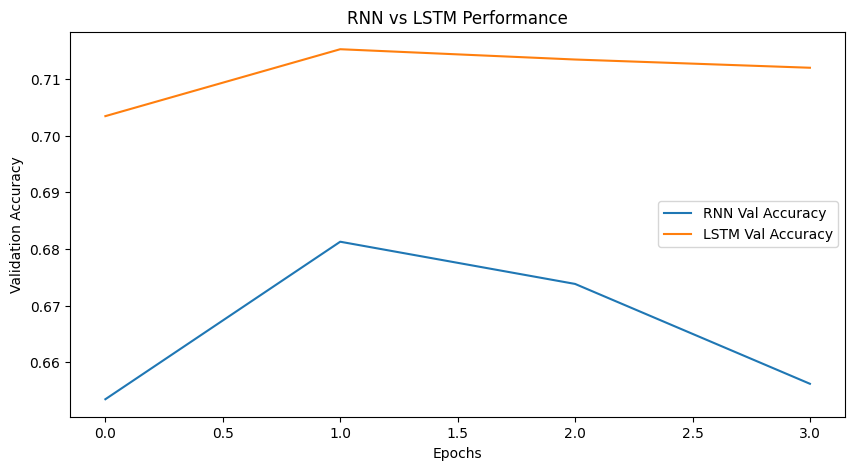

In [17]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['val_accuracy'], label='RNN Val Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('RNN vs LSTM Performance')
plt.legend()

plt.show()